<h4> The goal is to understand what drives economic growth (GDP per capita) and build a model to predict it <h4>

<h5> 1. Import <h5>

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
import os 
print(os.listdir())

['Untitled.ipynb', '.git', '.ipynb_checkpoints', 'README.md', 'P_Data_Extract_From_Health_Nutrition_and_Population_Statistics']


In [7]:
df = pd.read_csv("P_Data_Extract_From_Health_Nutrition_and_Population_Statistics/e1f98529-b0f5-4ccb-8118-00e0d30e8c08_Data.csv")

In [8]:
df.head()

,Series Name,Series Code,Country Name,Country Code,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024]
0,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,China,CHN,12.049,10.887,10.747,10.236,8.691,8.277,6.737,5.996,5.463,5.227,5.202
1,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,India,IND,28.806,18.194,14.535,15.166,15.133,14.796,14.423,14.289,14.185,14.06,13.036
2,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,Brazil,BRA,63.365,61.779,58.372,56.558,54.287,50.958,47.46,45.67,42.881,42.686,41.459
3,Adults (ages 15+) and children (0-14 years) li...,SH.HIV.TOTL,China,CHN,..,..,..,..,..,..,..,..,..,..,..
4,Adults (ages 15+) and children (0-14 years) li...,SH.HIV.TOTL,India,IND,..,..,..,..,..,..,..,..,..,..,2600000


In [9]:
df.columns

Index(['Series Name', 'Series Code', 'Country Name', 'Country Code',
       '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]',
       '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]',
       '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]'],
      dtype='object')

<h5> 2. Business Understanding <h5> 

In [10]:
#The goal of this exercise is to understand health metrics, such as infant mortality in Brazil, China, and India 

In [11]:
#Question 1: Which health and population factors have the strongest impact on infant mortality across countries?
#Question 2: What interesting or unexpected relationships exist between health indicators and infant mortality? 
#Question 3: How accurately can we predict infant mortality using health and population data? 
#Question 4: What would happen to infant mortality rates if a country improved key health indicators such as nutrition and healthcare access?

<h5> 3. Clean Data and Define Target <h5>

In [96]:
df_long = df.melt(
id_vars=["Country Name", "Series Name"],
var_name="Year",
value_name="Value")
df_long.head()

,Country Name,Series Name,Year,Value
0,China,"Adolescent fertility rate (births per 1,000 wo...",Series Code,SP.ADO.TFRT
1,India,"Adolescent fertility rate (births per 1,000 wo...",Series Code,SP.ADO.TFRT
2,Brazil,"Adolescent fertility rate (births per 1,000 wo...",Series Code,SP.ADO.TFRT
3,China,Adults (ages 15+) and children (0-14 years) li...,Series Code,SH.HIV.TOTL
4,India,Adults (ages 15+) and children (0-14 years) li...,Series Code,SH.HIV.TOTL


In [97]:
print(df_long.dtypes)

Country Name    object
Series Name     object
Year            object
Value           object
dtype: object


In [98]:
df_long["Value"]=pd.to_numeric(df_long["Value"], errors="coerce")

In [99]:
df_clean = df_long.pivot_table(
index=["Country Name", "Year"],
columns="Series Name",
values="Value").reset_index()

df_clean.head()

Series Name,Country Name,Year,AIDS estimated deaths (UNAIDS estimates),ARI treatment (% of children under 5 taken to a health provider),"Adolescent fertility rate (births per 1,000 women ages 15-19)",Adults (ages 15+) and children (0-14 years) living with HIV,Adults (ages 15+) and children (ages 0-14) newly infected with HIV,Adults (ages 15+) living with HIV,"Age at first marriage, female","Age at first marriage, male",...,Urban population,Urban population (% of total population),Urban population growth (annual %),Use of insecticide-treated bed nets (% of under-5 population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Wanted fertility rate (births per woman),Women who were first married by age 15 (% of women ages 20-24),Women who were first married by age 18 (% of women ages 20-24),Women's share of population ages 15+ living with HIV (%),Young people (ages 15-24) newly infected with HIV
0,Brazil,2014 [YR2014],13000.0,NaN,63.365,660000.0,65000.0,NaN,NaN,NaN,...,170939000.0,85.433137,1.117542,NaN,NaN,NaN,NaN,NaN,33.045705,NaN
1,Brazil,2015 [YR2015],14000.0,NaN,61.779,710000.0,67000.0,NaN,NaN,NaN,...,172822963.0,85.693570,1.096097,NaN,NaN,NaN,NaN,NaN,33.084235,NaN
2,Brazil,2016 [YR2016],13000.0,NaN,58.372,770000.0,68000.0,NaN,NaN,NaN,...,174663337.0,85.948705,1.059260,NaN,NaN,NaN,NaN,NaN,33.099971,NaN
3,Brazil,2017 [YR2017],12000.0,NaN,56.558,820000.0,69000.0,NaN,NaN,NaN,...,176450869.0,86.198290,1.018214,NaN,NaN,NaN,NaN,NaN,33.098750,NaN
4,Brazil,2018 [YR2018],12000.0,NaN,54.287,870000.0,69000.0,NaN,NaN,NaN,...,178163387.0,86.442072,0.965856,NaN,NaN,NaN,NaN,NaN,33.085784,NaN


In [100]:
print(df_clean.columns)

Index(['Country Name', 'Year', 'AIDS estimated deaths (UNAIDS estimates)',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Adults (ages 15+) and children (0-14 years) living with HIV',
       'Adults (ages 15+) and children (ages 0-14) newly infected with HIV',
       'Adults (ages 15+) living with HIV', 'Age at first marriage, female',
       'Age at first marriage, male',
       ...
       'Urban population', 'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'Use of insecticide-treated bed nets (% of under-5 population)',
       'Vitamin A supplementation coverage rate (% of children ages 6-59 months)',
       'Wanted fertility rate (births per woman)',
       'Women who were first married by age 15 (% of women ages 20-24)',
       'Women who were first married by age 18 (% of women ages 20-24)',
       'Women's share of population a

In [101]:
for col in df_clean.columns:
    if "infant" in col.lower():
        print(col)

Infant and young child feeding practices, all 3 IYCF (% children ages 6-23 months)
Mortality rate, infant (per 1,000 live births)
Mortality rate, infant, female (per 1,000 live births)
Mortality rate, infant, male (per 1,000 live births)
Number of infant deaths
Number of infant deaths, female
Number of infant deaths, male


In [114]:
target = "Mortality rate, infant (per 1,000 live births)"

In [127]:
df_numeric = df_clean.select_dtypes(include=[np.number])
df_numeric = df_numeric.fillna(df_numeric.mean())

In [133]:
cols_to_drop = [col for col in df_numeric.columns
                if "Mortality rate" in col.lower() and col !=target]

df_model = df_model.drop(columns=cols_to_drop)

In [134]:
corr = df_numeric.corr()
corr_target = corr[target].abs().sort_values(ascending=False)

print(corr_target.head(10))

Series Name
Mortality rate, infant (per 1,000 live births)                                 1.000000
Mortality rate, under-5, male (per 1,000)                                      0.999068
Mortality rate, neonatal (per 1,000 live births)                               0.998968
Mortality rate, under-5 (per 1,000)                                            0.998552
Mortality rate, infant, female (per 1,000 live births)                         0.998459
Mortality rate, infant, male (per 1,000 live births)                           0.998400
Probability of dying among adolescents ages 10-14 years, female (per 1,000)    0.997137
Probability of dying among adolescents ages 10-14 years (per 1,000)            0.996049
Mortality rate, under-5, female (per 1,000)                                    0.994824
Age dependency ratio, young                                                    0.991980
Name: Mortality rate, infant (per 1,000 live births), dtype: float64


In [135]:
print(df_numeric.columns)

Index(['AIDS estimated deaths (UNAIDS estimates)',
       'ARI treatment (% of children under 5 taken to a health provider)',
       'Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Adults (ages 15+) and children (0-14 years) living with HIV',
       'Adults (ages 15+) and children (ages 0-14) newly infected with HIV',
       'Adults (ages 15+) living with HIV', 'Age at first marriage, female',
       'Age at first marriage, male',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old',
       ...
       'Urban population', 'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'Use of insecticide-treated bed nets (% of under-5 population)',
       'Vitamin A supplementation coverage rate (% of children ages 6-59 months)',
       'Wanted fertility rate (births per woman)',
       'Women who were first married by age 15 (% of women ages 20-24)',
       'Women who were first married 

In [132]:
#have to manually select top features

In [139]:
features = ["Mortality rate, infant (per 1,000 live births)",
            "School enrollment, primary (% gross)",
            "School enrollment, primary (% net)",
            "Exclusive breastfeeding (% of children under 6 months)",
            "Contraceptive prevalence, any method (% of all women ages 15-49)",
            "Current health expenditure (% of GDP)",
            "Current health expenditure per capita (current US$)",
            "Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)",
            "Adolescent fertility rate (births per 1,000 women ages 15-19)",
            "Births attended by skilled health staff (% of total)"]

In [140]:
df_model = df_numeric[features]

In [141]:
target = "Mortality rate, infant (per 1,000 live births)"
X = df_model.drop(target, axis=1)
y = df_model[target]

In [142]:
print(X.shape)
print(y.shape)

(33, 9)
(33,)


<h5> 4. Plots <h5>

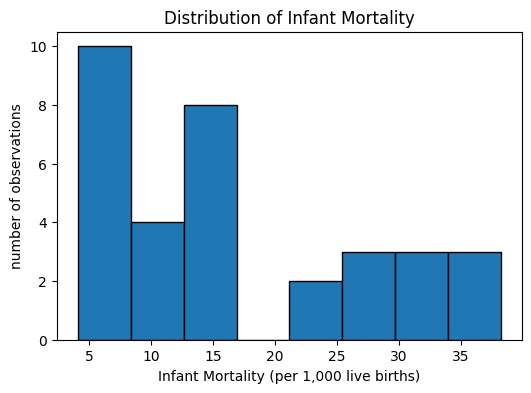

In [145]:
plt.figure(figsize=(6,4))
plt.hist(y, bins=8, edgecolor='black')
plt.title("Distribution of Infant Mortality")
plt.xlabel("Infant Mortality (per 1,000 live births)")
plt.ylabel("number of observations")

plt.show()

In [146]:
#plotting features for each country, makes it more interpretable 

In [149]:
#School Enrolment 

In [150]:
feature1 = "School enrollment, primary (% gross)"

Text(0.5, 0, 'Year')

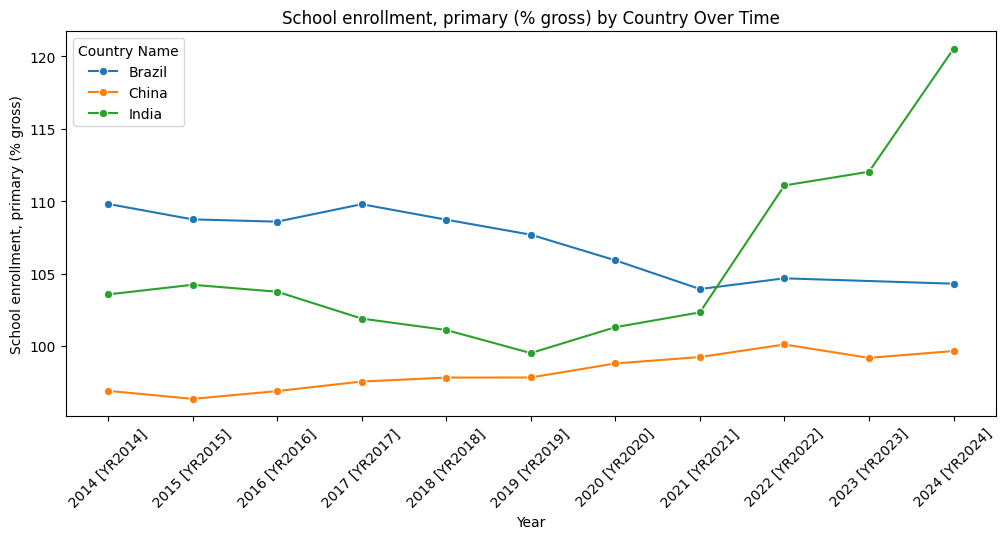

In [153]:
plt.figure(figsize=(12,5))

sns.lineplot(
data=df_clean,
x="Year",
y=feature1,
hue="Country Name",
marker="o")
plt.xticks(rotation=45)

plt.title(f"{feature1} by Country Over Time")
plt.ylabel(feature1)
plt.xlabel("Year")

In [158]:
feature2 = "Current health expenditure (% of GDP)"

Text(0.5, 0, 'Year')

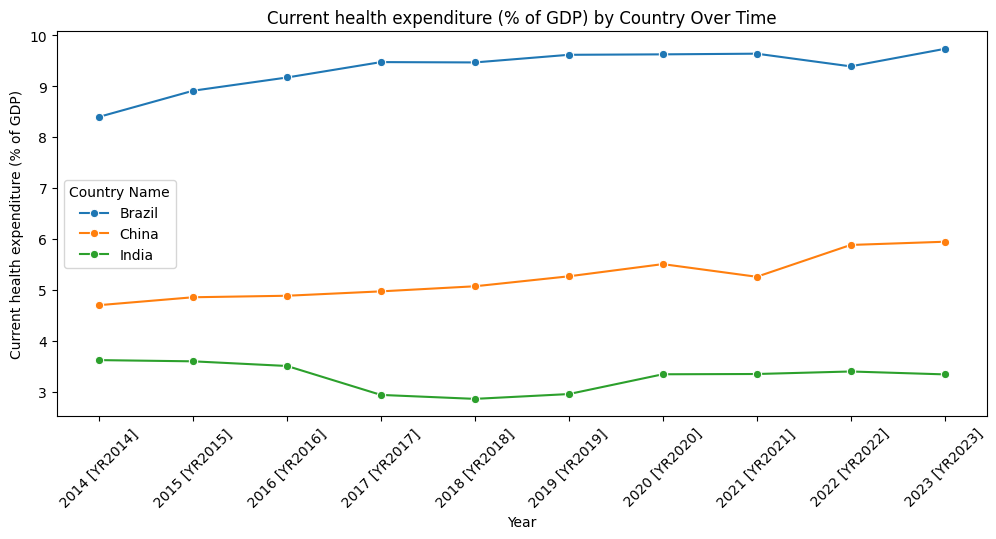

In [159]:
plt.figure(figsize=(12,5))

sns.lineplot(
data=df_clean,
x="Year",
y=feature2,
hue="Country Name",
marker="o")
plt.xticks(rotation=45)

plt.title(f"{feature2} by Country Over Time")
plt.ylabel(feature2)
plt.xlabel("Year")

In [160]:
feature3 = "Births attended by skilled health staff (% of total)"

Text(0.5, 0, 'Year')

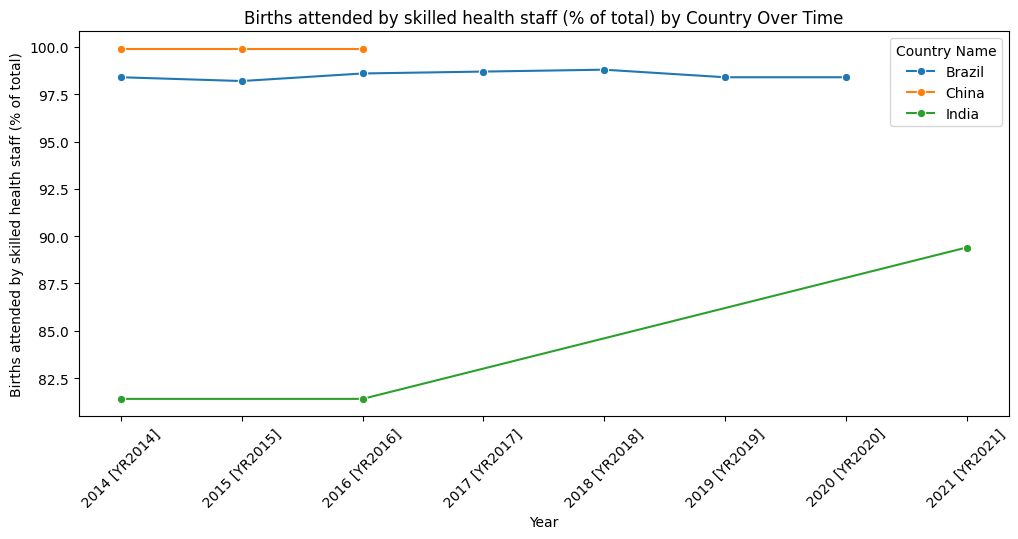

In [161]:
plt.figure(figsize=(12,5))

sns.lineplot(
data=df_clean,
x="Year",
y=feature3,
hue="Country Name",
marker="o")
plt.xticks(rotation=45)

plt.title(f"{feature3} by Country Over Time")
plt.ylabel(feature3)
plt.xlabel("Year")

In [162]:
feature4 = "Adolescent fertility rate (births per 1,000 women ages 15-19)"

Text(0.5, 0, 'Year')

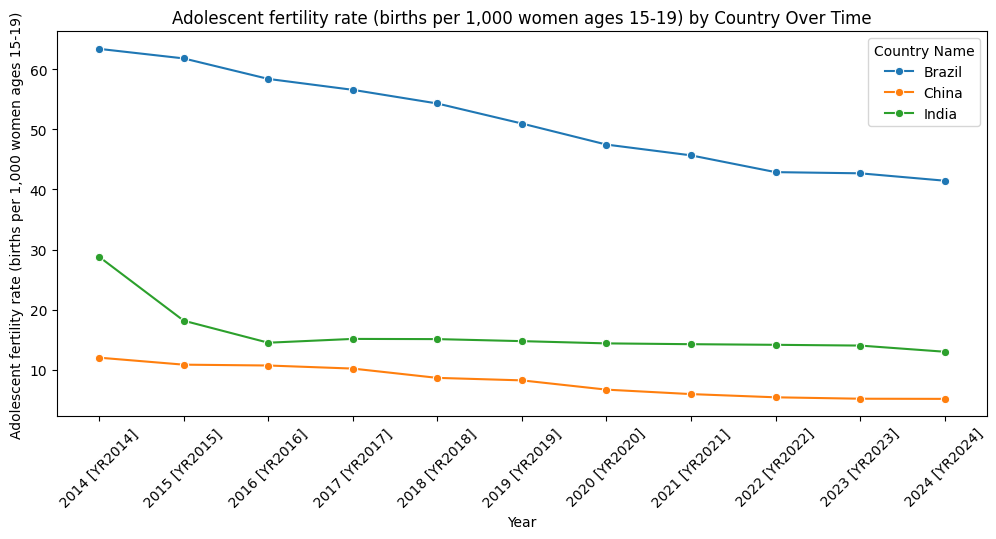

In [163]:
plt.figure(figsize=(12,5))

sns.lineplot(
data=df_clean,
x="Year",
y=feature4,
hue="Country Name",
marker="o")
plt.xticks(rotation=45)

plt.title(f"{feature4} by Country Over Time")
plt.ylabel(feature4)
plt.xlabel("Year")

In [164]:
#these features were chosen because they have enough data across all three countries 

<h5> 5. Relationship with Target <h5>

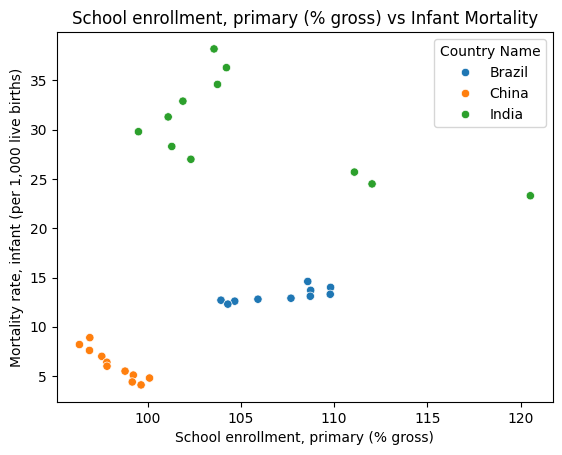

In [168]:
sns.scatterplot(
data=df_clean,
x=feature1,
y=target,
hue="Country Name")

plt.title(f"{feature1} vs Infant Mortality")
plt.show()

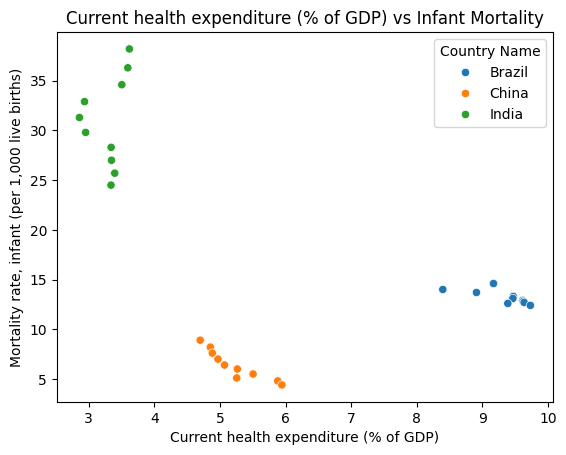

In [166]:
sns.scatterplot(
data=df_clean,
x=feature2,
y=target,
hue="Country Name")

plt.title(f"{feature2} vs Infant Mortality")
plt.show()

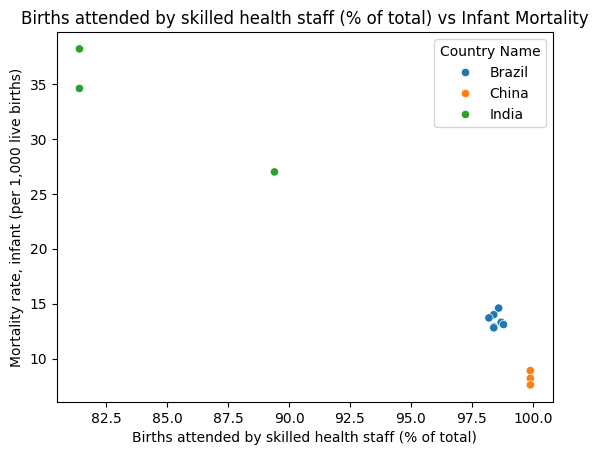

In [167]:
sns.scatterplot(
data=df_clean,
x=feature3,
y=target,
hue="Country Name")

plt.title(f"{feature3} vs Infant Mortality")
plt.show()

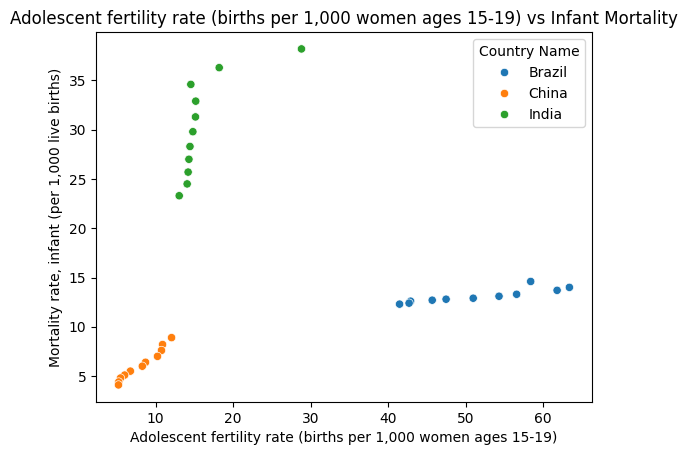

In [169]:
sns.scatterplot(
data=df_clean,
x=feature4,
y=target,
hue="Country Name")

plt.title(f"{feature4} vs Infant Mortality")
plt.show()

In [181]:
#interesting insights, downward trend on a few features 

<h5> 6. Model <h5>

In [183]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [184]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [187]:
from sklearn.metrics import mean_squared_error, r2_score 
import numpy as np 

y_pred = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("r^2:", r2_score(y_test,y_pred))

RMSE: 6.605611751223363
r^2: 0.514154223902655


In [188]:
base = X.iloc[[0]].copy()

In [197]:
improved = base.copy()

improved["School enrollment, primary (% gross)"] *= 1.1
improved["Current health expenditure (% of GDP)"]*= 1.2
improved["Births attended by skilled health staff (% of total)"]*= 1.1

In [198]:
baseline_pred = model.predict(base)[0]
improved_pred = model.predict(improved)[0]

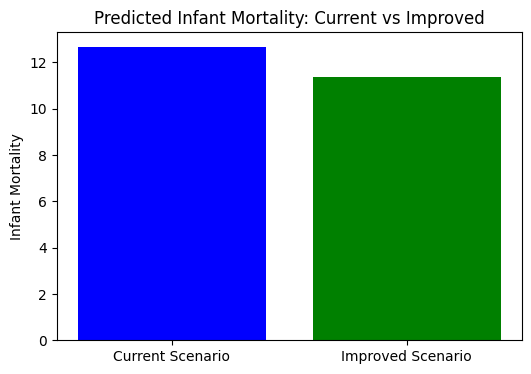

In [199]:
values = [baseline_pred, improved_pred]
labels = ["Current Scenario", "Improved Scenario"]

plt.figure(figsize=(6,4))

plt.bar(labels, values, color=["blue", "green"])

plt.title("Predicted Infant Mortality: Current vs Improved")
plt.ylabel("Infant Mortality")

plt.show()

In [ ]:
#marginal reduction but an improvement in infant mortality 